In [1]:
import kagglehub
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, roc_auc_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import(Input, Dense)
from tensorflow.keras.callbacks import(EarlyStopping)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Dateset shape after cleaning: (283726, 31)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 14s 14ms/step - loss: 0.7751 - val_loss: 0.6526
Epoch 2/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.5996 - val_loss: 0.5796
Epoch 3/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.5499 - val_loss: 0.5398
Epoch 4/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.5198 - val_loss: 0.5152
Epoch 5/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5017 - val_loss: 0.5000
Epoch 6/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4877 - val_loss: 0.4876
Epoch 7/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4759 - val_loss: 0.4780
Epoch 8/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4673 - val_loss: 0.4710
Epoch 9/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4605 - val_loss: 0.4663
Epoch 10/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4567 - val_loss: 0.4639
Epoch 11/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.4543 - val_loss: 0.4621
Epoch 12/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/st

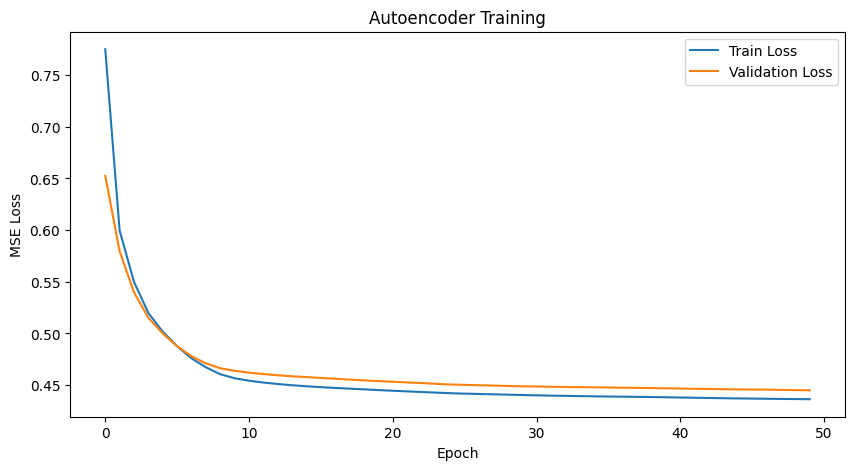

7082/7082 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


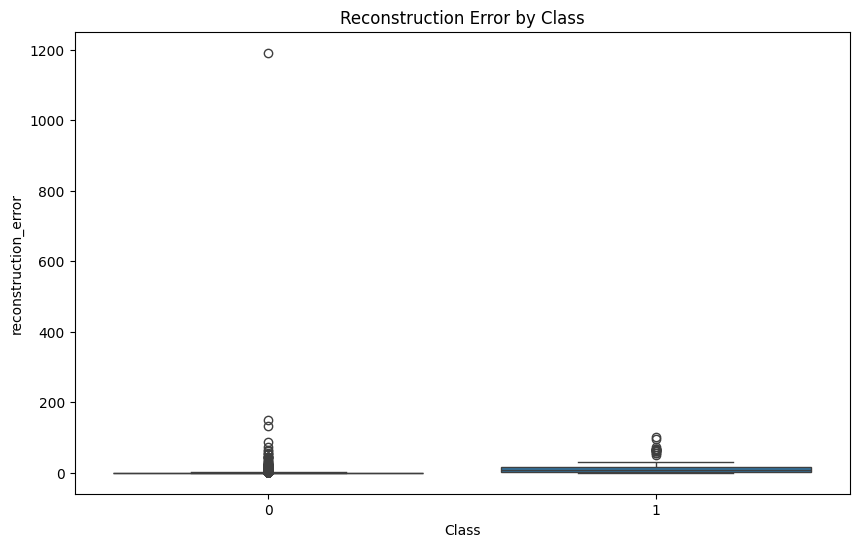

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.15      0.58      0.24        95

    accuracy                           0.99     56746
   macro avg       0.57      0.79      0.62     56746
weighted avg       1.00      0.99      1.00     56746

ROC-AUC Score: 0.9145


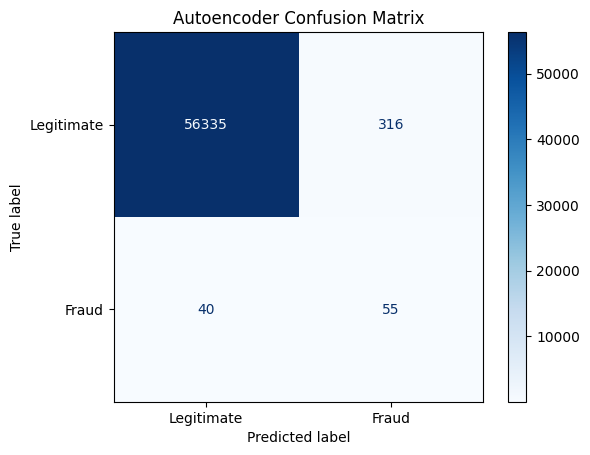

In [2]:
# Load Dataset
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_file = Path(path) / "creditcard.csv"

df = pd.read_csv(csv_file)
# df.head()

# Remove duplicate transactions
df = df.drop_duplicates()
print("Dateset shape after cleaning:", df.shape)


#--------------------
# Features und Target
#--------------------
X = df.drop("Class", axis=1)
y = df["Class"]

#--------------------
# Train-Test-Split
#--------------------
stratify = y
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

#--------------------
# Feature Scaling
#--------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#----------------------------------
# Train only on normal transactions
#----------------------------------
X_train_normal = X_train_scaled[y_train == 0]
X_train_normal.shape

#--------------------
# Buil Autoencoder
#--------------------
input_dim = X_train_normal.shape[1]
input_layer = Input(shape=(input_dim,))
encoder = Dense(16, activation = "relu")(input_layer)
encoder = Dense(8, activation = "relu")(encoder)
decoder = Dense(16, activation = "relu")(encoder)
decoder = Dense(input_dim, activation="linear")(decoder)
autoencoder = Model(inputs = input_layer, outputs = decoder)

#--------------------
# Compile
#--------------------
autoencoder.compile(optimizer = "adam", loss = "mse")
autoencoder.summary()

#--------------------
# Early Stopping
#--------------------
early_stopping = EarlyStopping(monitor = "val_loss", patience = 5, restore_best_weights = True)

#--------------------
# Train Autoencoder
#--------------------
history = autoencoder.fit(X_train_normal, X_train_normal,epochs = 50, batch_size = 256,
                          validation_split = 0.2, callbacks = [early_stopping], verbose = 1)

#--------------------
# Training History
#--------------------
plt.figure(figsize = (10, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label = "Validation Loss")
plt.title("Autoencoder Training")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

#-------------------------------
# Training Reconstruction Error
#-------------------------------
train_pred = autoencoder.predict(X_train_normal)
train_error = np.mean(np.square(X_train_normal - train_pred), axis = 1)

#----------------------
# Reconstruction Error
#----------------------
X_test_pred = autoencoder.predict(X_test_scaled)
reconstruction_error = np.mean(np.square(X_test_scaled - X_test_pred), axis = 1)
reconstruction_error[:5]

#----------------------
# Error Distribution
#----------------------
error_df = pd.DataFrame({"reconstruction_error": reconstruction_error, "Class": y_test.values})
plt.figure(figsize = (10,6))
sns.boxplot(x = "Class", y = "reconstruction_error", data = error_df)
plt.title("Reconstruction Error by Class")
plt.show()

#----------------------
# Threshold Selection
#----------------------
threshold = np.percentile(train_error, 99.5)
threshold

#----------------------
# Fraud Prediction
#----------------------
y_pred = (reconstruction_error > threshold).astype(int)

#----------------------
# Evaluation
#----------------------
print(classification_report(y_test, y_pred))

#----------------------
# ROC-AUC
#----------------------
roc_auc = roc_auc_score(y_test, reconstruction_error)
print(f"ROC-AUC Score: {roc_auc:.4f}")

#--------------------
# Confusion Matrix
#--------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ["Legitimate", "Fraud"])
disp.plot(cmap = "Blues")
plt.title("Autoencoder Confusion Matrix")
plt.show()


## Autoencoder Results

The Autoencoder was trained exclusively on legitimate transactions and used reconstruction error to identify anomalous behavior.

### Training Behavior

The training and validation loss decreased steadily throughout training, indicating successful learning of normal transaction patterns without evidence of severe overfitting.

### Classification Performance

- Precision: 0.15
- Recall: 0.58
- F1-Score: 0.24
- ROC-AUC: 0.915

The model correctly identified 55 of 95 fraudulent transactions but generated a relatively large number of false positive predictions.

### Reconstruction Error Analysis

Fraudulent transactions generally produced higher reconstruction errors than legitimate transactions.

The reconstruction error distributions demonstrate that the Autoencoder learned normal transaction behavior reasonably well. However, a substantial overlap between the two classes limited the model's ability to perfectly separate fraud cases from legitimate transactions.

### Threshold Selection

A reconstruction error threshold was determined from the distribution of reconstruction errors on normal training transactions.

Transactions with reconstruction errors exceeding this threshold were classified as anomalous and therefore considered potential fraud cases.

### Model Interpretation

Unlike Logistic Regression, Random Forest, and Deep Neural Networks, the Autoencoder operates as an unsupervised anomaly detection model.

Instead of learning fraud labels directly, it learns to reconstruct normal transactions and identifies observations that deviate from this learned behavior.

This approach can be useful when fraud labels are unavailable or when fraud patterns continuously evolve over time.

### Comparison with Supervised Models

The Autoencoder achieved lower predictive performance than the supervised learning approaches evaluated in this project.

While the model was able to detect anomalous transactions, the significantly lower precision and F1-score indicate that supervised methods were more effective for this dataset.

Nevertheless, the Autoencoder demonstrates the potential of anomaly detection techniques for fraud detection scenarios where labeled examples are limited or unavailable.